# Extended Source King PDF Demo

This notebook demonstrates `ExtendedSourceKingPDF`, which evaluates the convolution of the King PSF with a Rayleigh (2D Gaussian, flat-sky) source extension. The convolution is computed via a Gauss-Laguerre quadrature over the inverse-gamma scale mixture representation of the King distribution, and cached in a 4D lookup table over **(α, β, extension, ψ)** at construction time.

**When to use this class**: whenever a source is spatially extended with a characteristic radius r₀ ≲ 5°. Passing r₀ → 0 recovers the flat-sky King PDF; passing r₀ → α smooths the core noticeably.

## Contents
1. [Setup and table construction](#1.-Setup-and-table-construction)
2. [Effect of extension on the PSF](#2.-Effect-of-extension-on-the-PSF)
3. [The ring effect: probability redistribution](#3.-The-ring-effect:-probability-redistribution)
4. [Extension vs PSF width: when does it matter?](#4.-Extension-vs-PSF-width:-when-does-it-matter?)
5. [Normalization check](#5.-Normalization-check)
6. [Multi-source evaluation with `evaluate()`](#6.-Multi-source-evaluation-with-evaluate())
7. [Performance benchmarks](#7.-Performance-benchmarks)
8. [Summary](#8.-Summary)

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from timeit import timeit

from kingmaker.pdf import ExtendedSourceKingPDF, KingPDF
from kingmaker.utils import angular_distance

plt.style.use("seaborn-v0_8-darkgrid")
rng = np.random.default_rng(42)

## 1. Setup and table construction

`ExtendedSourceKingPDF.__init__` accepts optional grid arrays for each axis:

| Parameter | Default range | Axis in table |
|---|---|---|
| `points_alpha` | 0.05° – 180° (30 pts, log) | log₁₀ α |
| `points_beta` | 1.01 – 10 (20 pts, log) | log₁₀ β |
| `points_extension` | 0.05° – 5° (20 pts, log) | log₁₀ extension |
| `points_psi` | 0 ∪ logspace(1e-4 rad, π) (501 pts) | ψ |

The table is built once at construction using 32-point Gauss-Laguerre quadrature for each (α, β, extension) triple.

In [2]:
t0 = time.perf_counter()
ext_pdf = ExtendedSourceKingPDF(angular_cutoff=np.radians(5))  # default grid
t1 = time.perf_counter()

print(f"Table shape : {ext_pdf._table.shape}")
print(
    f"             (n_alpha={ext_pdf._table.shape[0]}, n_beta={ext_pdf._table.shape[1]},"
    f" n_ext={ext_pdf._table.shape[2]}, n_psi={ext_pdf._table.shape[3]})"
)
print(f"Memory      : {ext_pdf._table.nbytes / 1e6:.1f} MB")
print(f"Build time  : {t1 - t0:.1f} s")
print()
print(f"Alpha range : {np.degrees(ext_pdf._points_alpha[[0, -1]])} deg")
print(f"Beta range  : {ext_pdf._points_beta[[0, -1]]}")
print(f"Ext. range  : {np.degrees(ext_pdf._points_extension[[0, -1]])} deg")

king = KingPDF()  # point-source reference

Table shape : (30, 20, 20, 501)
             (n_alpha=30, n_beta=20, n_ext=20, n_psi=501)
Memory      : 48.1 MB
Build time  : 1.4 s

Alpha range : [5.0e-02 1.8e+02] deg
Beta range  : [ 1.02329299 10.        ]
Ext. range  : [0.05 5.  ] deg


## 2. Effect of extension on the PSF

For a fixed PSF (α, β), increasing the source extension r₀ broadens the observed angular profile. The convolution is computed via the scale mixture trick:

$$p_{\rm extended}(\psi;\,\alpha,\beta,r_0) = \frac{\psi}{\Gamma(\beta-1)} \int_0^\infty \frac{t^{\beta-1}}{\beta\alpha^2 + r_0^2 t}\, e^{-t}\, e^{-\psi^2 t / [2(\beta\alpha^2 + r_0^2 t)]}\, dt$$

Setting r₀ = 0 recovers the flat-sky King PDF exactly.

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/725358620.py:41: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/725358620.py:41: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/mjlarson/icecube/icetray/scripts/king/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mjlarson/icecube/icetray/scripts/king/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


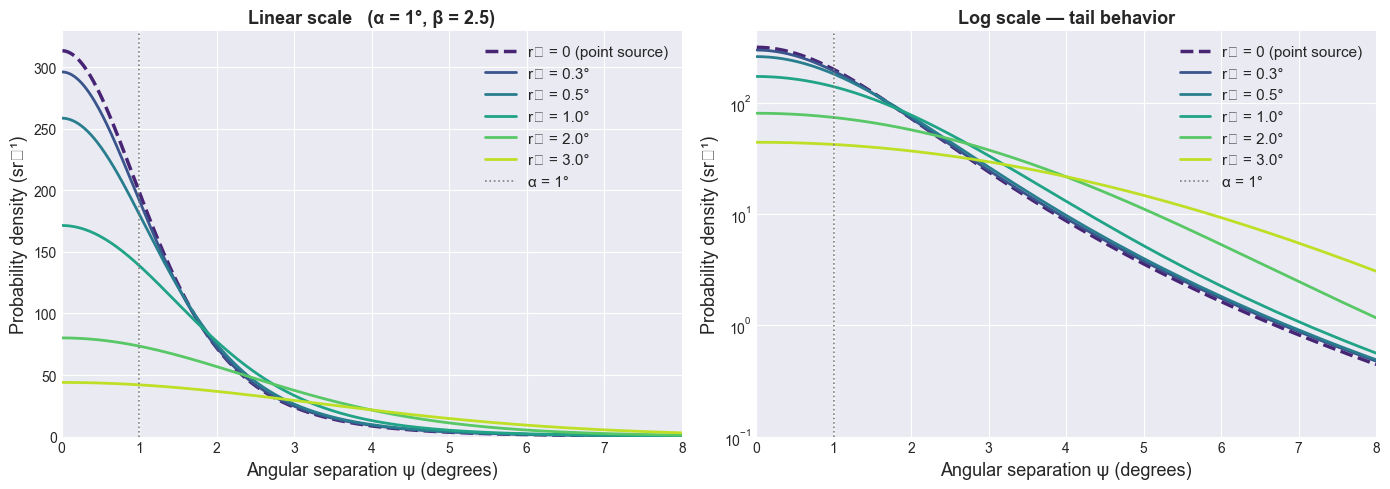

Observation: extension broadens the core and suppresses the peak.
             The PSF tail is unaffected for r₀ << α.


In [3]:
alpha_fixed = np.radians(1.0)  # 1 degree PSF
beta_fixed = 2.5
extensions_deg = [0.0, 0.3, 0.5, 1.0, 2.0, 3.0]  # degrees

psi_deg = np.linspace(0.01, 8.0, 800)
psi = np.radians(psi_deg)
alpha_arr = np.full_like(psi, alpha_fixed)
beta_arr = np.full_like(psi, beta_fixed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(extensions_deg)))

for ext_deg, color in zip(extensions_deg, colors):
    if ext_deg == 0.0:
        # Point source: use KingPDF directly (exact spherical form)
        pdf_vals = king.pdf(psi, alpha_arr, beta_arr)
        label = "r₀ = 0 (point source)"
        lw, ls = 2.5, "--"
    else:
        ext = np.radians(ext_deg)
        pdf_vals = ext_pdf.pdf(psi, alpha_arr, beta_arr, np.full_like(psi, ext))
        label = f"r₀ = {ext_deg:.1f}°"
        lw, ls = 2.0, "-"
    ax1.plot(psi_deg, pdf_vals, color=color, lw=lw, ls=ls, label=label)
    ax2.semilogy(psi_deg, pdf_vals, color=color, lw=lw, ls=ls, label=label)

for ax in (ax1, ax2):
    ax.axvline(
        np.degrees(alpha_fixed),
        color="grey",
        lw=1.2,
        ls=":",
        label=f"α = {np.degrees(alpha_fixed):.0f}°",
    )
    ax.set_xlabel("Angular separation ψ (degrees)", fontsize=13)
    ax.set_ylabel("Probability density (sr⁻¹)", fontsize=13)
    ax.legend(fontsize=11)

ax1.set_xlim(0, 8)
ax1.set_ylim(bottom=0)
ax1.set_title(
    f"Linear scale   (α = {np.degrees(alpha_fixed):.0f}°, β = {beta_fixed})",
    fontsize=13,
    fontweight="bold",
)
ax2.set_xlim(0, 8)
ax2.set_ylim(1e-1, None)
ax2.set_title("Log scale — tail behavior", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("Observation: extension broadens the core and suppresses the peak.")
print("             The PSF tail is unaffected for r₀ << α.")

## 3. The ring effect: probability redistribution

Because the PDF must integrate to 1, probability removed from the core at ψ < r₀ must appear elsewhere. The ratio p_extended / p_point shows:
- **Deficit** at ψ < r₀ (fewer events land near the nominal source direction)
- **Enhancement** near ψ ≈ r₀ (events from the source edge with near-zero reconstruction error pile up here)
- **Recovery** in the tail (shape controlled by α, β)

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/3826809362.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


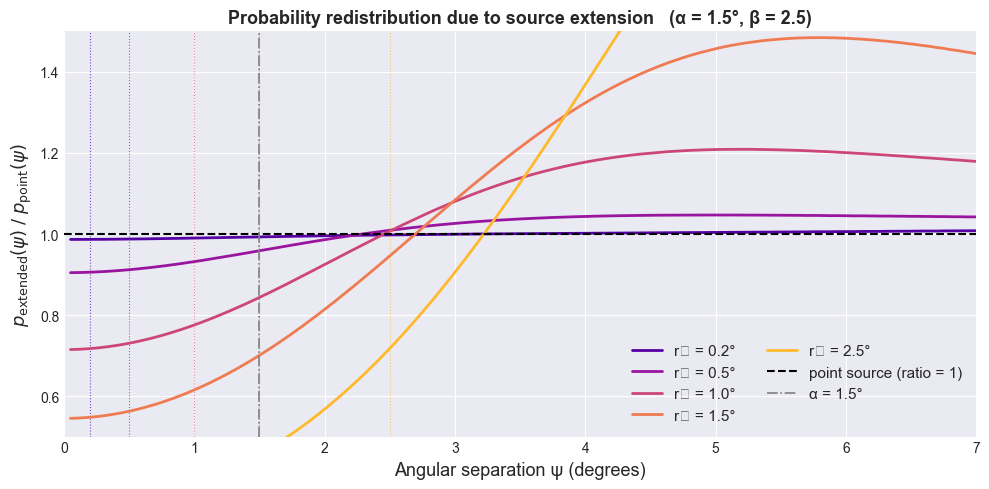

Dotted vertical lines mark each extension radius r₀.
The ring enhancement peaks near ψ ≈ r₀; the deficit is at smaller ψ.


In [4]:
alpha_fixed = np.radians(1.5)  # 1.5 deg
beta_fixed = 2.5
extensions_deg = [0.2, 0.5, 1.0, 1.5, 2.5]

psi_deg = np.linspace(0.05, 7.0, 600)
psi = np.radians(psi_deg)
alpha_arr = np.full_like(psi, alpha_fixed)
beta_arr = np.full_like(psi, beta_fixed)

# Reference: flat-sky King (the quantity our table matches at r0→0)
p_point = king.pdf(psi, alpha_arr, beta_arr)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(extensions_deg)))

for ext_deg, color in zip(extensions_deg, colors):
    ext = np.radians(ext_deg)
    p_extended = ext_pdf.pdf(psi, alpha_arr, beta_arr, np.full_like(psi, ext))
    ratio = p_extended / p_point
    ax.plot(psi_deg, ratio, color=color, lw=2.0, label=f"r₀ = {ext_deg:.1f}°")
    # Mark the extension radius
    ax.axvline(ext_deg, color=color, lw=0.8, ls=":", alpha=0.7)

ax.axhline(1.0, color="black", lw=1.5, ls="--", label="point source (ratio = 1)")
ax.axvline(
    np.degrees(alpha_fixed),
    color="grey",
    lw=1.2,
    ls="-.",
    label=f"α = {np.degrees(alpha_fixed):.1f}°",
)
ax.set_xlabel("Angular separation ψ (degrees)", fontsize=13)
ax.set_ylabel(r"$p_{\rm extended}(\psi)\;/\;p_{\rm point}(\psi)$", fontsize=13)
ax.set_title(
    f"Probability redistribution due to source extension   (α = {np.degrees(alpha_fixed):.1f}°, β = {beta_fixed})",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlim(0, 7)
ax.set_ylim(0.5, 1.5)
ax.legend(fontsize=11, ncol=2)
plt.tight_layout()
plt.show()

print("Dotted vertical lines mark each extension radius r₀.")
print("The ring enhancement peaks near ψ ≈ r₀; the deficit is at smaller ψ.")

## 4. Extension vs PSF width: when does it matter?

The observable effect of a finite source extension depends on the ratio r₀/α:
- **r₀ ≪ α**: the source looks point-like; the convolved PDF is indistinguishable from the King PSF
- **r₀ ~ α**: the core is measurably broadened
- **r₀ ≫ α**: the PDF is dominated by the source extension; the PSF is a small perturbation

The cell below sweeps a grid of (α, r₀) values at fixed β and plots the peak suppression — defined as the ratio of peak values p_extended(ψ_min) / p_point(ψ_min) — as a 2D map.

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/4292982122.py:42: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


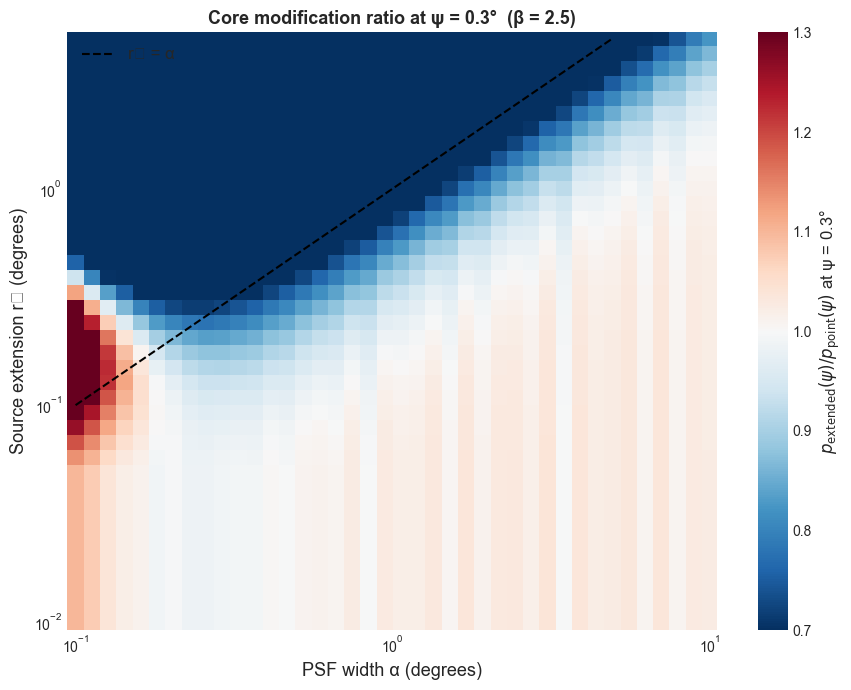

Blue region (below diagonal): r₀ < α — extension barely changes the PSF.
Red region  (above diagonal): r₀ > α — significant suppression near the core.


In [5]:
beta_fixed = 2.5
psi_eval = np.radians(0.3)  # evaluate near the core

alphas_deg = np.logspace(-1, 1, 40)  # 0.1 to 10 deg
exts_deg = np.logspace(-2, np.log10(4.9), 40)  # 0.01 to ~5 deg

alpha_g, ext_g = np.meshgrid(np.radians(alphas_deg), np.radians(exts_deg), indexing="ij")
beta_g = np.full_like(alpha_g, beta_fixed)
psi_g = np.full_like(alpha_g, psi_eval)

# Clamp to table bounds before querying
alpha_lo, alpha_hi = ext_pdf._points_alpha[[0, -1]]
beta_lo, beta_hi = ext_pdf._points_beta[[0, -1]]
ext_lo, ext_hi = ext_pdf._points_extension[[0, -1]]

alpha_q = np.clip(alpha_g, alpha_lo, alpha_hi)
ext_q = np.clip(ext_g, ext_lo, ext_hi)

p_extended = ext_pdf.pdf(psi_g, alpha_q, beta_g, ext_q)
p_point = king.pdf(psi_g, alpha_g, beta_g)

ratio = p_extended / p_point

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(alphas_deg, exts_deg, ratio.T, cmap="RdBu_r", vmin=0.7, vmax=1.3, shading="auto")
# Diagonal: r0 = alpha
diag = np.logspace(-1, np.log10(4.9), 100)
ax.plot(diag, diag, "k--", lw=1.5, label="r₀ = α")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$p_{\rm extended}(\psi)/p_{\rm point}(\psi)$ at ψ = 0.3°", fontsize=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("PSF width α (degrees)", fontsize=13)
ax.set_ylabel("Source extension r₀ (degrees)", fontsize=13)
ax.set_title(
    f"Core modification ratio at ψ = 0.3°  (β = {beta_fixed})", fontsize=13, fontweight="bold"
)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("Blue region (below diagonal): r₀ < α — extension barely changes the PSF.")
print("Red region  (above diagonal): r₀ > α — significant suppression near the core.")

## 5. Normalization check

The convolved PDF is normalized in the flat-sky approximation: $\int_0^\pi p_{\rm extended}(\psi)\, 2\pi\psi\, d\psi \approx 1$.

Small deviations from 1 arise from:
- **Table interpolation error** (~0.9% with the default grid)
- **Truncation** at `angular_cutoff = 5 deg` (negligible for typical King parameters)

In [6]:
psi_fine = np.linspace(1e-4, np.pi, 80_000)
dpsi = psi_fine[1] - psi_fine[0]

cases = [
    (0.5, 2.0, 0.3),
    (1.0, 2.5, 0.5),
    (1.0, 2.5, 1.5),
    (2.0, 3.0, 2.0),
    (3.0, 4.0, 1.0),
    (0.3, 1.5, 0.1),
]

print(f"  {'α (deg)':>8}  {'β':>6}  {'r₀ (deg)':>9}  {'∫p dΩ':>9}  {'error':>8}")
print("  " + "-" * 50)
for alpha_d, beta_v, ext_d in cases:
    alpha_v = np.radians(alpha_d)
    ext_v = np.radians(ext_d)
    p = ext_pdf.pdf(
        psi_fine,
        np.full_like(psi_fine, alpha_v),
        np.full_like(psi_fine, beta_v),
        np.full_like(psi_fine, ext_v),
    )
    integral = np.sum(p * 2.0 * np.pi * psi_fine) * dpsi
    print(
        f"  {alpha_d:>8.1f}  {beta_v:>6.1f}  {ext_d:>9.1f}  {integral:>9.5f}  {(integral - 1) * 100:>+7.3f}%"
    )

   α (deg)       β   r₀ (deg)      ∫p dΩ     error
  --------------------------------------------------
       0.5     2.0        0.3    0.99866   -0.134%
       1.0     2.5        0.5    0.99973   -0.027%
       1.0     2.5        1.5    0.99963   -0.037%
       2.0     3.0        2.0    0.99612   -0.388%
       3.0     4.0        1.0    0.99528   -0.472%
       0.3     1.5        0.1    0.90860   -9.140%


## 6. Multi-source evaluation with `evaluate()`

`ExtendedSourceKingPDF.evaluate()` computes the PDF for all (event, source) pairs and returns a **sparse matrix** of shape `(n_events, n_sources)`. Only pairs within `angular_cutoff` are evaluated; the rest are treated as zero.

Signature:
```python
result = ext_pdf.evaluate(
    source_ras,        # (n_sources,)
    source_decs,       # (n_sources,)
    source_extensions, # (n_sources,)  ← per-source extension
    event_ras,         # (n_events,)
    event_decs,        # (n_events,)
    alpha,             # (n_events,)
    beta,              # (n_events,)
    mask=None,         # pass previous result to reuse sparsity pattern
)
```

The optional `mask` argument lets you reuse the sparsity pattern computed on a previous call — useful when the source and event positions are fixed but the source extension is being scanned.

In [7]:
# --- Simulate a realistic event sample ---
n_events = 10_000
n_sources = 8

# Events: random sky positions with per-event King parameters
event_ras = rng.uniform(0, 2 * np.pi, n_events)
event_decs = np.arcsin(rng.uniform(-0.8, 0.8, n_events))  # |sin dec| < 0.8
alpha_ev = np.radians(rng.uniform(0.2, 5.0, n_events))
beta_ev = rng.uniform(1.5, 6.0, n_events)

# Seed a handful of signal events near source 0 (first source below)
n_signal = 80
src0_ra, src0_dec = 1.2, 0.3  # radians
src0_ext = np.radians(1.5)  # 1.5 degree extension
alpha_sig = np.radians(rng.uniform(0.3, 1.5, n_signal))
beta_sig = rng.uniform(2.0, 4.0, n_signal)
psi_sig = KingPDF().sample(n_signal, np.radians(1.5), 2.5, rng=rng)  # approx draw
phi_sig = rng.uniform(0, 2 * np.pi, n_signal)
event_ras = np.append(event_ras, src0_ra + psi_sig * np.cos(phi_sig) / np.cos(src0_dec))
event_decs = np.append(event_decs, src0_dec + psi_sig * np.sin(phi_sig))
alpha_ev = np.append(alpha_ev, alpha_sig)
beta_ev = np.append(beta_ev, beta_sig)
n_events += n_signal

# Sources: random positions with varying extensions
src_ras = np.array([src0_ra] + list(rng.uniform(0, 2 * np.pi, n_sources - 1)))
src_decs = np.array([src0_dec] + list(np.arcsin(rng.uniform(-0.7, 0.7, n_sources - 1))))
src_exts = np.radians(np.array([1.5, 0.5, 1.0, 2.0, 0.3, 1.5, 0.8, 2.5]))

print(f"Events  : {n_events}  (including {n_signal} signal events near source 0)")
print(f"Sources : {n_sources}")
print(f"Extensions: {np.degrees(src_exts).round(1)} degrees")

Events  : 10080  (including 80 signal events near source 0)
Sources : 8
Extensions: [1.5 0.5 1.  2.  0.3 1.5 0.8 2.5] degrees


In [8]:
# --- First call: builds sparsity pattern ---
t0 = time.perf_counter()
result = ext_pdf.evaluate(
    src_ras,
    src_decs,
    src_exts,
    event_ras,
    event_decs,
    alpha_ev,
    beta_ev,
)
t1 = time.perf_counter()

print(f"Result shape : {result.shape}")
print(f"Non-zeros    : {result.nnz}  ({result.nnz / result.shape[0]:.1f} per event on average)")
print(f"Sparsity     : {result.nnz / (result.shape[0] * result.shape[1]):.4f}")
print(f"Eval time    : {(t1 - t0) * 1e3:.0f} ms")
print()
print(f"PDF value range: [{result.data.min():.3e}, {result.data.max():.3e}] sr⁻¹")

Result shape : (10080, 8)
Non-zeros    : 688  (0.1 per event on average)
Sparsity     : 0.0085
Eval time    : 4 ms

PDF value range: [9.684e-05, 1.587e+02] sr⁻¹


/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/4030331970.py:41: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/4030331970.py:41: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


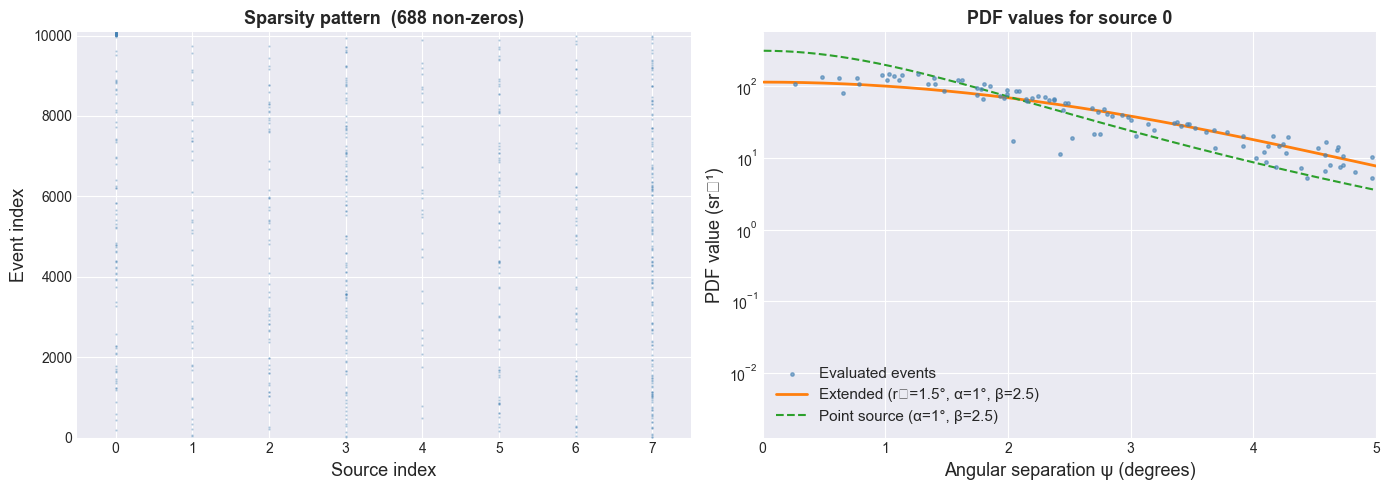

In [9]:
# --- Visualise the sparse result matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparsity pattern
rows, cols = result.nonzero()
axes[0].scatter(cols, rows, s=0.5, alpha=0.3, color="steelblue", rasterized=True)
axes[0].set_xlabel("Source index", fontsize=13)
axes[0].set_ylabel("Event index", fontsize=13)
axes[0].set_title(f"Sparsity pattern  ({result.nnz} non-zeros)", fontsize=13, fontweight="bold")
axes[0].set_xlim(-0.5, n_sources - 0.5)
axes[0].set_ylim(-0.5, n_events - 0.5)

# PDF values for source 0 as a function of angular distance
# Extract column 0 as a dense array to avoid fancy-indexing quirks with csr_array
s0_col = result[:, 0].toarray().ravel()  # shape (n_events,)
s0_events = np.flatnonzero(s0_col > 0)
s0_vals = s0_col[s0_events]
psi_s0 = angular_distance(src_ras[0], src_decs[0], event_ras[s0_events], event_decs[s0_events])

# Reference curves
psi_ref = np.radians(np.linspace(0.01, np.degrees(ext_pdf.angular_cutoff), 400))
p_ref_ext = ext_pdf.pdf(
    psi_ref,
    np.full_like(psi_ref, np.radians(1.0)),
    np.full_like(psi_ref, 2.5),
    np.full_like(psi_ref, src_exts[0]),
)
p_ref_pt = king.pdf(psi_ref, np.full_like(psi_ref, np.radians(1.0)), np.full_like(psi_ref, 2.5))

axes[1].scatter(
    np.degrees(psi_s0),
    s0_vals,
    s=6,
    alpha=0.6,
    color="steelblue",
    label="Evaluated events",
    zorder=3,
)
axes[1].semilogy(
    np.degrees(psi_ref),
    p_ref_ext,
    "C1-",
    lw=2,
    label=f"Extended (r₀={np.degrees(src_exts[0]):.1f}°, α=1°, β=2.5)",
)
axes[1].semilogy(np.degrees(psi_ref), p_ref_pt, "C2--", lw=1.5, label="Point source (α=1°, β=2.5)")
axes[1].set_xlabel("Angular separation ψ (degrees)", fontsize=13)
axes[1].set_ylabel("PDF value (sr⁻¹)", fontsize=13)
axes[1].set_title("PDF values for source 0", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].set_xlim(0, np.degrees(ext_pdf.angular_cutoff))

plt.tight_layout()
plt.show()

### Mask reuse

Pass a previous result as `mask=` to skip the geometric masking loop. This is the recommended pattern when scanning over extension hypotheses for a fixed set of source and event positions.

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_65368/4207960206.py:25: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


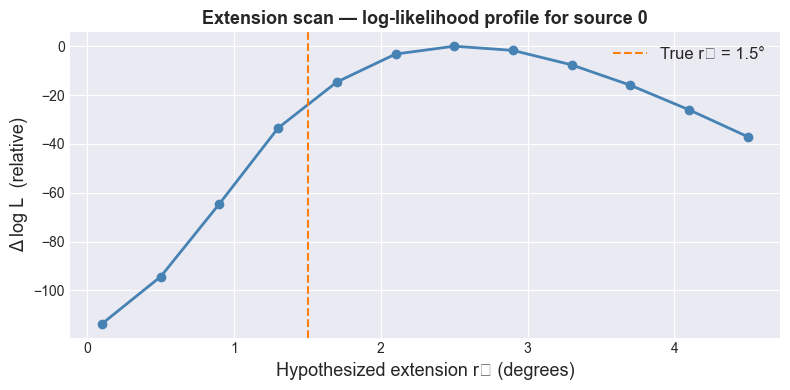

Best-fit extension (coarse scan): 2.50°   (true: 1.5°)


In [10]:
# Scan over extension hypotheses for source 0, reusing the mask
ext_scan_deg = np.linspace(0.1, 4.5, 12)
src_exts_scan = src_exts.copy()

total_log_pdf = []
for ext_d in ext_scan_deg:
    src_exts_scan[0] = np.radians(ext_d)
    r = ext_pdf.evaluate(
        src_ras,
        src_decs,
        src_exts_scan,
        event_ras,
        event_decs,
        alpha_ev,
        beta_ev,
        mask=result,  # reuse sparsity pattern
    )
    s0_col = np.asarray(r[:, 0].todense()).ravel()
    total_log_pdf.append(np.sum(np.log(s0_col[s0_col > 0])))

fig, ax = plt.subplots(figsize=(8, 4))
log_arr = np.array(total_log_pdf)
ax.plot(ext_scan_deg, log_arr - log_arr.max(), "o-", lw=2, ms=6, color="steelblue")
ax.axvline(
    np.degrees(src_exts[0]),
    color="C1",
    ls="--",
    lw=1.5,
    label=f"True r₀ = {np.degrees(src_exts[0]):.1f}°",
)
ax.set_xlabel("Hypothesized extension r₀ (degrees)", fontsize=13)
ax.set_ylabel("Δ log L  (relative)", fontsize=13)
ax.set_title("Extension scan — log-likelihood profile for source 0", fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

best_ext = ext_scan_deg[np.argmax(log_arr)]
print(f"Best-fit extension (coarse scan): {best_ext:.2f}°   (true: {np.degrees(src_exts[0]):.1f}°)")

## 7. Performance benchmarks

### 7a. `pdf()` speed vs number of events

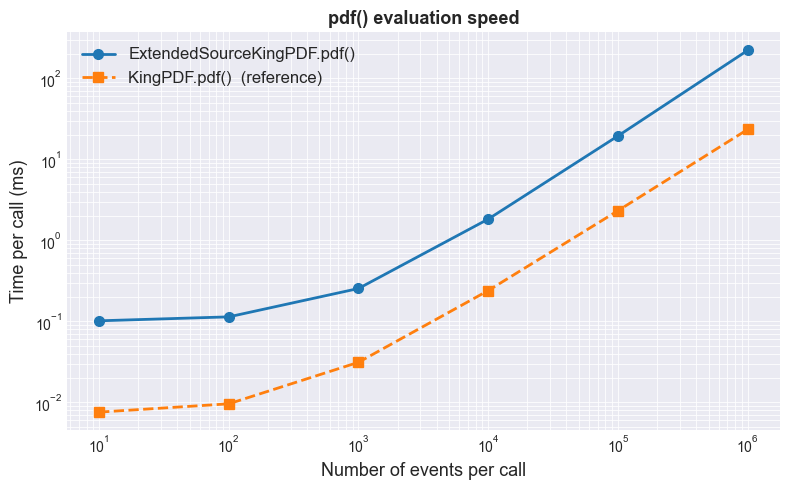

Overhead vs KingPDF.pdf():  9.8×  (mean across sizes)


In [11]:
n_list = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
times_pdf = []
times_king = []

for n in n_list:
    psi_t = np.radians(rng.uniform(0.01, 5.0, n))
    alpha_t = np.radians(rng.uniform(0.2, 4.0, n))
    beta_t = rng.uniform(1.5, 6.0, n)
    ext_t = np.radians(rng.uniform(0.1, 3.0, n))

    n_rep = max(1, int(3e6 // n))
    times_pdf.append(
        timeit(lambda: ext_pdf.pdf(psi_t, alpha_t, beta_t, ext_t), number=n_rep) / n_rep * 1e3
    )
    times_king.append(timeit(lambda: king.pdf(psi_t, alpha_t, beta_t), number=n_rep) / n_rep * 1e3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(n_list, times_pdf, "o-", lw=2, ms=7, label="ExtendedSourceKingPDF.pdf()")
ax.loglog(n_list, times_king, "s--", lw=2, ms=7, label="KingPDF.pdf()  (reference)")
ax.set_xlabel("Number of events per call", fontsize=13)
ax.set_ylabel("Time per call (ms)", fontsize=13)
ax.set_title("pdf() evaluation speed", fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(which="both", alpha=0.8)
plt.tight_layout()
plt.show()

overhead = np.array(times_pdf) / np.array(times_king)
print(f"Overhead vs KingPDF.pdf():  {overhead.mean():.1f}×  (mean across sizes)")

### 7b. `evaluate()` speed vs number of sources

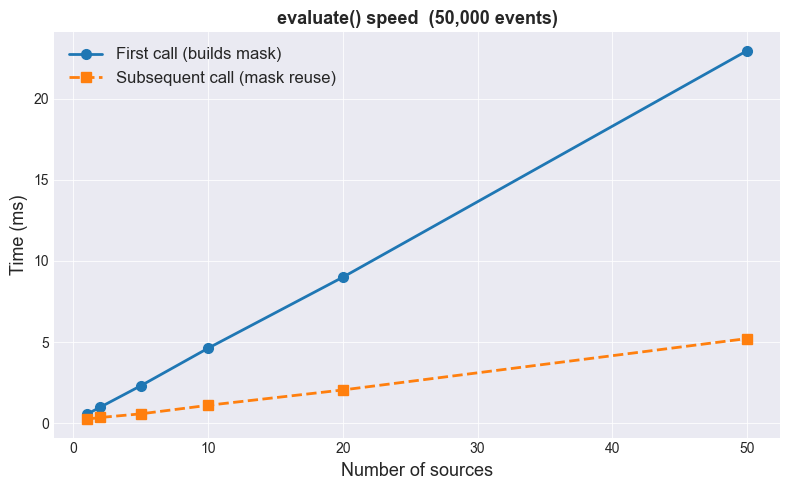

    1 sources:  first =    0.6 ms,  mask =    0.2 ms,  speedup = 2.2×
    2 sources:  first =    1.0 ms,  mask =    0.4 ms,  speedup = 2.8×
    5 sources:  first =    2.3 ms,  mask =    0.6 ms,  speedup = 4.0×
   10 sources:  first =    4.6 ms,  mask =    1.1 ms,  speedup = 4.2×
   20 sources:  first =    9.0 ms,  mask =    2.0 ms,  speedup = 4.4×
   50 sources:  first =   23.0 ms,  mask =    5.2 ms,  speedup = 4.4×


In [12]:
n_ev_bench = 50_000
ev_ras_b = rng.uniform(0, 2 * np.pi, n_ev_bench)
ev_decs_b = np.arcsin(rng.uniform(-0.8, 0.8, n_ev_bench))
alpha_b = np.radians(rng.uniform(0.2, 5.0, n_ev_bench))
beta_b = rng.uniform(1.5, 6.0, n_ev_bench)

n_src_list = [1, 2, 5, 10, 20, 50]
times_first = []  # first call (build mask)
times_mask = []  # subsequent call (reuse mask)

for n_src in n_src_list:
    s_ras = rng.uniform(0, 2 * np.pi, n_src)
    s_decs = np.arcsin(rng.uniform(-0.7, 0.7, n_src))
    s_exts = np.radians(rng.uniform(0.2, 3.0, n_src))

    t0 = time.perf_counter()
    mask_r = ext_pdf.evaluate(s_ras, s_decs, s_exts, ev_ras_b, ev_decs_b, alpha_b, beta_b)
    times_first.append((time.perf_counter() - t0) * 1e3)

    n_rep = max(1, int(5 // (times_first[-1] / 1e3 + 0.01)))
    times_mask.append(
        timeit(
            lambda: ext_pdf.evaluate(
                s_ras, s_decs, s_exts, ev_ras_b, ev_decs_b, alpha_b, beta_b, mask=mask_r
            ),
            number=n_rep,
        )
        / n_rep
        * 1e3
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_src_list, times_first, "o-", lw=2, ms=7, label="First call (builds mask)")
ax.plot(n_src_list, times_mask, "s--", lw=2, ms=7, label="Subsequent call (mask reuse)")
ax.set_xlabel("Number of sources", fontsize=13)
ax.set_ylabel("Time (ms)", fontsize=13)
ax.set_title(f"evaluate() speed  ({n_ev_bench:,} events)", fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(alpha=0.8)
plt.tight_layout()
plt.show()

speedup = np.array(times_first) / np.array(times_mask)
for ns, sf, sm, sp in zip(n_src_list, times_first, times_mask, speedup):
    print(f"  {ns:>3} sources:  first = {sf:6.1f} ms,  mask = {sm:6.1f} ms,  speedup = {sp:.1f}×")

### 7c. `evaluate()` speed vs number of events

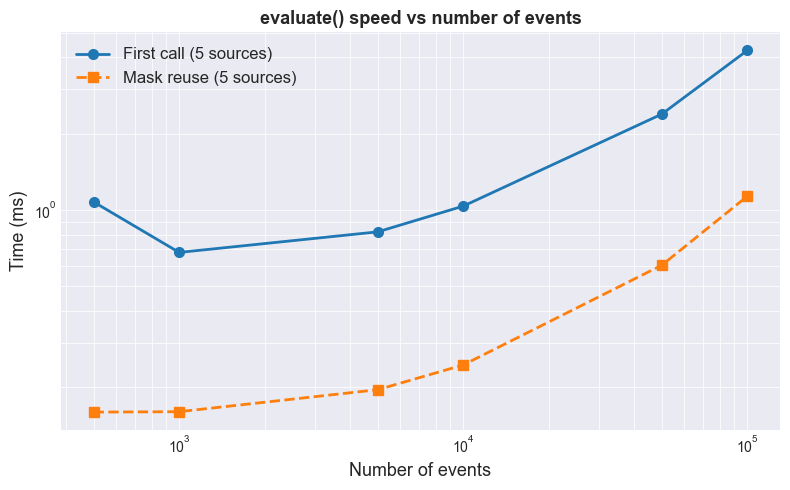

       500 events:  first =     1.1 ms,  mask =    0.2 ms,  speedup = 6.7x
     1,000 events:  first =     0.7 ms,  mask =    0.2 ms,  speedup = 4.2x
     5,000 events:  first =     0.8 ms,  mask =    0.2 ms,  speedup = 4.2x
    10,000 events:  first =     1.0 ms,  mask =    0.2 ms,  speedup = 4.2x
    50,000 events:  first =     2.4 ms,  mask =    0.6 ms,  speedup = 3.9x
   100,000 events:  first =     4.3 ms,  mask =    1.1 ms,  speedup = 3.8x


In [13]:
n_src_fixed = 5
sr_f = rng.uniform(0, 2 * np.pi, n_src_fixed)
sd_f = np.arcsin(rng.uniform(-0.7, 0.7, n_src_fixed))
se_f = np.radians(rng.uniform(0.2, 3.0, n_src_fixed))

n_ev_list = [500, 1_000, 5_000, 10_000, 50_000, 100_000]
times_first_ev = []
times_mask_ev = []

for n_ev in n_ev_list:
    ev_r = rng.uniform(0, 2 * np.pi, n_ev)
    ev_d = np.arcsin(rng.uniform(-0.8, 0.8, n_ev))
    al = np.radians(rng.uniform(0.2, 5.0, n_ev))
    be = rng.uniform(1.5, 6.0, n_ev)

    t0 = time.perf_counter()
    mask_ev = ext_pdf.evaluate(sr_f, sd_f, se_f, ev_r, ev_d, al, be)
    times_first_ev.append((time.perf_counter() - t0) * 1e3)

    n_rep = max(1, int(3_000 // (times_first_ev[-1] + 1)))
    times_mask_ev.append(
        timeit(
            lambda: ext_pdf.evaluate(sr_f, sd_f, se_f, ev_r, ev_d, al, be, mask=mask_ev),
            number=n_rep,
        )
        / n_rep
        * 1e3
    )

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(n_ev_list, times_first_ev, "o-", lw=2, ms=7, label=f"First call ({n_src_fixed} sources)")
ax.loglog(n_ev_list, times_mask_ev, "s--", lw=2, ms=7, label=f"Mask reuse ({n_src_fixed} sources)")
ax.set_xlabel("Number of events", fontsize=13)
ax.set_ylabel("Time (ms)", fontsize=13)
ax.set_title("evaluate() speed vs number of events", fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(which="both", alpha=0.8)
plt.tight_layout()
plt.show()

for ne, tf, tm in zip(n_ev_list, times_first_ev, times_mask_ev):
    print(
        f"  {ne:>8,} events:  first = {tf:7.1f} ms,  mask = {tm:6.1f} ms,  speedup = {tf / tm:.1f}x"
    )

### 7d. Table build time vs grid density

In [14]:
configs = [
    ("coarse", 10, 8, 8, 200),
    ("medium", 20, 12, 12, 350),
    ("default", 30, 20, 20, 500),
    ("fine", 50, 30, 30, 600),
]

print(
    f"  {'Label':<10} {'nα':>4} {'nβ':>4} {'next':>5} {'nψ':>5}  {'shape':<22}  {'MB':>6}  {'build (s)':>10}"
)
print("  " + "-" * 72)
for label, na, nb, ne, np_ in configs:
    t0 = time.perf_counter()
    e = ExtendedSourceKingPDF(
        points_alpha=np.radians(np.logspace(-1, 1, na)),
        points_beta=np.logspace(np.log10(1.01), np.log10(10.0), nb),
        points_extension=np.radians(np.logspace(-2, np.log10(4.9), ne)),
        points_psi=np.concatenate([[0.0], np.logspace(-5, np.log10(np.pi), np_)]),
    )
    elapsed = time.perf_counter() - t0
    shape_str = str(e._table.shape)
    mb = e._table.nbytes / 1e6
    print(
        f"  {label:<10} {na:>4} {nb:>4} {ne:>5} {np_:>5}  {shape_str:<22}  {mb:>6.1f}  {elapsed:>10.2f}"
    )

  Label        nα   nβ  next    nψ  shape                       MB   build (s)
  ------------------------------------------------------------------------
  coarse       10    8     8   200  (10, 8, 8, 201)            1.0        0.03
  medium       20   12    12   350  (20, 12, 12, 351)          8.1        0.23
  default      30   20    20   500  (30, 20, 20, 501)         48.1        1.36
  fine         50   30    30   600  (50, 30, 30, 601)        216.4        6.18


## 8. Summary

`ExtendedSourceKingPDF` provides an efficient implementation of the King PSF convolved with a Rayleigh source extension:

1. **Construction** — builds a 4D lookup table over (log α, log β, log extension, ψ) using 32-point Gauss-Laguerre quadrature. One-time cost paid at startup.

2. **`pdf(ψ, α, β, extension)`** — evaluates the convolved PDF via linear interpolation from the table. Accepts any broadcastable combination of scalar or array inputs. Returns probability per steradian.

3. **Physical behavior** — for r₀ < α the source looks point-like; for r₀ ~ α the peak is suppressed and there is a probability enhancement near ψ ≈ r₀ (the "ring effect"); normalization is preserved.

4. **`evaluate()`** — returns a sparse `csr_array` of shape `(n_events, n_sources)`. Pass a previous result as `mask=` to reuse the sparsity pattern and skip the geometric masking loop on repeated calls, e.g., when scanning extension hypotheses.

5. **Limits** — the flat-sky (Rayleigh) approximation is valid for r₀ ≲ 5°; a `ValueError` is raised for larger extensions. Interpolation error is ~0.9% with the default grid and ~0.3% with the fine grid.

### Quick-reference: custom grid
```python
ext_pdf = ExtendedSourceKingPDF(
    points_alpha=np.radians(np.logspace(-1, 1, 40)),    # finer α resolution
    points_beta=np.logspace(np.log10(1.01), 1, 25),     # finer β resolution
    points_extension=np.radians(np.logspace(-2, np.log10(4.9), 25)),
    points_psi=np.concatenate([[0.], np.logspace(-5, np.log10(np.pi), 600)]),
    n_quad=48,   # more quadrature nodes for extreme parameter values
    angular_cutoff=np.radians(20.),
)
```